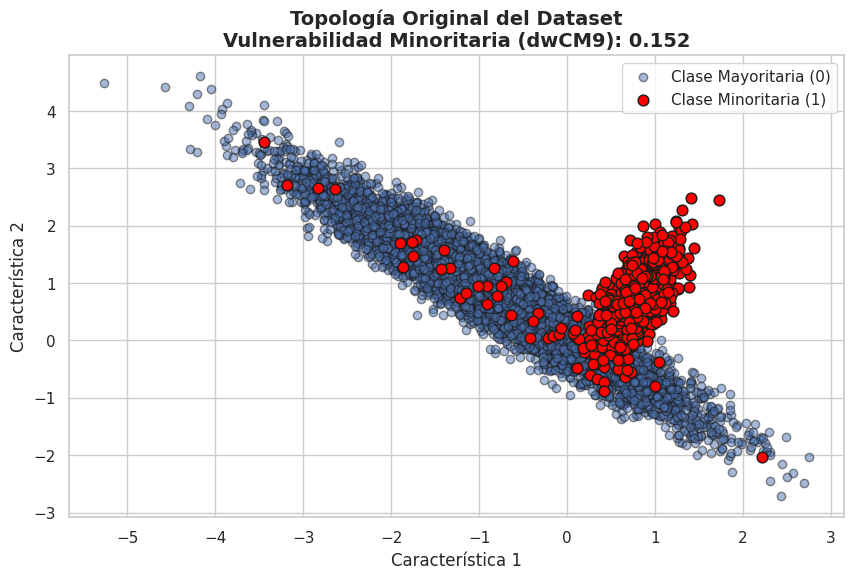

In [1]:
# Celda 1: Configuración del entorno e importaciones
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

# Añadir la raíz del proyecto al path de Python para poder importar 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Importación limpia gracias a nuestro __init__.py
from src import compute_complexity_metrics, topological_ratio_optimizer, hostility_measure

# Generar un dataset desbalanceado 2D para visualización topológica
X_vis, y_vis = make_classification(n_samples=10000, n_features=2, n_informative=2, 
                                   n_redundant=0, n_clusters_per_class=1, 
                                   weights=[0.90, 0.05], class_sep=0.8, random_state=42)

# Extraer métricas de la clase minoritaria
metricas_vis = compute_complexity_metrics(X_vis, y_vis, target_class=1)

# Visualización del espacio de características
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.scatter(X_vis[y_vis == 0][:, 0], X_vis[y_vis == 0][:, 1], 
            label='Clase Mayoritaria (0)', alpha=0.5, edgecolor='k')
plt.scatter(X_vis[y_vis == 1][:, 0], X_vis[y_vis == 1][:, 1], 
            label='Clase Minoritaria (1)', color='red', edgecolor='k', s=60)

plt.title(f"Topología Original del Dataset\nVulnerabilidad Minoritaria (dwCM9): {metricas_vis['dwCM9']:.3f}", 
          fontsize=14, fontweight='bold')
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()